# MALL CUSTOMER SPENDING & INCOME SEGMENTATION ANALYSIS
### An End-to-End Unsupervised Machine Learning Framework for Customer Personality, Purchasing Traits & Behavioral Profiling

---

## Executive Project Overview
In retail and commercial mall ecosystems, understanding customer diversity is paramount for personalized marketing, churn prevention, and revenue optimization. Rather than treating all shoppers homogeneously, **Customer Personality & Segmentation Analysis** leverages empirical transaction histories to discover latent customer personas based on actual spending power, purchasing frequency, and engagement latency.

### Core Project Highlights & Methodologies:
1. **Data Ingestion & Integrity**: Processed large-scale retail transaction records (`data.csv`, 541,909 rows) containing multi-country purchasing transactions.
2. **Behavioral Feature Engineering**: Synthesized RFM fundamentals (Recency, Frequency, Monetary) alongside **Estimated Annual Income Capacity**, **Spending Score (1-100)**, **Average Order Value (AOV)**, and **Product Diversity**.
3. **Categorical Encoding & Feature Standardization**: Applied `LabelEncoder` to geographic identifiers and `StandardScaler` to align multidimensional feature variances ($\mu=0, \sigma=1$).
4. **Dimensionality Reduction (PCA)**: Extracted 3 orthogonal principal components capturing **>82% of total cumulative variance**, addressing collinearity and facilitating 2D/3D geometric visualization.
5. **Hyperparameter Optimization**: Evaluated Within-Cluster Sum of Squares (WCSS) across $k \in [1, 14]$ and deployed the **`KneeLocator`** algorithm (`kneed` library) to objectively identify **$k=5$ optimal clusters**, reinforced by **Silhouette Analysis**.
6. **Persona Profiling & Commercial Strategy**: Mapped each cluster to an actionable business archetype (*VIP High-Spenders, Wholesale Giants, Active Regulars, At-Risk Occasionals, International Buyers*) with dedicated retention and revenue expansion roadmaps.


In [1]:
# Import core computational, statistical, and machine learning packages
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn tools for preprocessing, decomposition, clustering, and evaluation
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from kneed import KneeLocator

# Configure global visualization parameters
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.autolayout'] = False

print("Environment setup successful! All core libraries loaded.")


Environment setup successful! All core libraries loaded.


### Workflow Phase 1: Environment & Tooling Rationale
- **`pandas` & `numpy`**: Serve as the backbone for high-performance tabular manipulation, vectorized operations, and aggregation across half a million records.
- **`matplotlib` & `seaborn`**: Provide publication-grade aesthetic charting with precise control over DPI, color palettes, subplots, and 3D geometric projections.
- **`scikit-learn`**: Delivers production-grade implementations of `StandardScaler`, `PCA`, `KMeans`, and validation metrics (`silhouette_score`).
- **`kneed.KneeLocator`**: Automates the mathematical detection of the point of maximum curvature (knee/elbow) along the WCSS objective curve, eliminating subjective visual guessing.


In [2]:
# Load the raw transaction dataset
data_path = 'data.csv'
df_raw = pd.read_csv(data_path, encoding='ISO-8859-1')

print(f"Dataset Loaded Successfully!")
print(f"Total Transactions (Rows): {df_raw.shape[0]:,}")
print(f"Total Attributes (Columns): {df_raw.shape[1]}")
print("\n--- Column Schema & Data Types ---")
print(df_raw.dtypes)

print("\n--- Missing Value Audit ---")
missing_summary = pd.DataFrame({
    'Missing Values': df_raw.isnull().sum(),
    'Percentage (%)': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
print(missing_summary[missing_summary['Missing Values'] > 0])

print("\n--- First 5 Records ---")
display(df_raw.head())


Dataset Loaded Successfully!
Total Transactions (Rows): 541,909
Total Attributes (Columns): 8

--- Column Schema & Data Types ---
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

--- Missing Value Audit ---


             Missing Values  Percentage (%)
Description            1454            0.27
CustomerID           135080           24.93

--- First 5 Records ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Workflow Phase 2: Transaction Audit & Cleaning Strategy
1. **Missing Customer Identifiers**: A significant portion (~24.9%) of transaction rows lack a `CustomerID`. Because customer segmentation fundamentally requires tracking unique individuals across their purchasing lifetime, guest checkouts without an associated ID cannot be clustered and must be excluded.
2. **Transaction Date Parsing**: `InvoiceDate` must be converted to native `datetime64` format to enable temporal calculations (Recency and shopping velocity).
3. **Cancellations & Negative Quantities**: Invoices prefixed with `'C'` represent merchandise returns or order cancellations. We identify these to accurately compute true net customer spend while capturing cancellation propensity as an independent behavioral indicator.
4. **Line-Item Total Valuation**: We calculate line revenue as $\text{TotalPrice} = \text{Quantity} \times \text{UnitPrice}$.


In [3]:
# 1. Filter records with valid CustomerID
df_clean = df_raw.dropna(subset=['CustomerID']).copy()
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# 2. Parse InvoiceDate and compute total transaction price
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# 3. Flag cancelled transactions (prefix 'C')
df_clean['IsCancelled'] = df_clean['InvoiceNo'].astype(str).str.startswith('C').astype(int)

print(f"Cleaned Transactions Count: {len(df_clean):,}")
print(f"Unique Customers Represented: {df_clean['CustomerID'].nunique():,}")
print(f"Date Range: {df_clean['InvoiceDate'].min().strftime('%Y-%m-%d')} to {df_clean['InvoiceDate'].max().strftime('%Y-%m-%d')}")


Cleaned Transactions Count: 406,829
Unique Customers Represented: 4,372
Date Range: 2010-12-01 to 2011-12-09


### Workflow Phase 3: Customer Personality & Behavioral Feature Engineering
To perform meaningful customer segmentation, raw line-level transactions are aggregated into customer-level behavioral signatures. We construct a multi-dimensional personality profile for every customer:

1. **Recency ($R$)**: Days between the customer's last observed purchase and the end-of-dataset reference snapshot ($T_{\text{snapshot}} = \max(\text{Date}) + 1\text{ day}$). Lower recency indicates active engagement.
2. **Frequency ($F$)**: Total distinct shopping trips / invoices ($N_{\text{invoices}}$). Reflects loyalty and brand preference.
3. **Monetary Value ($M$)**: Cumulative net spend across all shopping excursions ($\sum \text{TotalPrice}$). Measures revenue contribution.
4. **Estimated Annual Income / Purchasing Power Index**: In retail analytics where customer tax filings are unobservable, spending velocity annualized over customer lifecycle serves as an accurate proxy for financial purchasing capacity:
   $$\text{EstimatedAnnualIncome} = M \times \left(\frac{365}{\max(R + 15, 15)}\right)$$
5. **Spending Score ($1 - 100$)**: A normalized benchmark reflecting the customer's spending percentile relative to the upper quartile of the customer base.
6. **Average Order Value (AOV)**: Mean expenditure per transaction excursion ($\text{AOV} = M / F$).
7. **Total Quantity & Product Diversity**: Total items purchased and distinct product varieties (`nunique(StockCode)`).
8. **Country / Regional Demographic**: Geographic location of the customer.


In [4]:
# Set snapshot baseline date for Recency calculation
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group transactions by CustomerID to extract behavioral features
cust_df = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': lambda x: x.nunique(),
    'TotalPrice': 'sum',
    'Quantity': 'sum',
    'UnitPrice': 'mean',
    'StockCode': 'nunique',
    'Country': 'first',
    'IsCancelled': 'sum'
}).reset_index()

# Rename columns
cust_df.columns = [
    'CustomerID', 'Recency', 'Frequency', 'Monetary',
    'TotalQuantity', 'AvgUnitPrice', 'ProductDiversity',
    'Country', 'CancelledInvoices'
]

# Ensure positive net monetary value and quantities
cust_df = cust_df[(cust_df['Monetary'] > 0) & (cust_df['TotalQuantity'] > 0)].copy()

# Derive advanced retail behavioral indices
cust_df['EstimatedAnnualIncome'] = cust_df['Monetary'] * (365.0 / np.maximum(cust_df['Recency'] + 15, 15))
cust_df['SpendingScore'] = np.clip((cust_df['Monetary'] / cust_df['Monetary'].quantile(0.95)) * 100, 1, 100)
cust_df['AvgOrderValue'] = cust_df['Monetary'] / np.maximum(cust_df['Frequency'], 1)

print(f"Total Validated Customer Profiles: {len(cust_df):,}")
display(cust_df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])


Total Validated Customer Profiles: 4,315


,count,mean,std,min,50%,max
CustomerID,4315.0,15300.016222,1719.710375,12347.000000,15299.000000,1.828700e+04
Recency,4315.0,90.349942,99.162620,1.000000,49.000000,3.740000e+02
Frequency,4315.0,5.120278,9.391335,1.000000,3.000000,2.480000e+02
Monetary,4315.0,1926.380870,8269.509136,2.900000,658.260000,2.794890e+05
TotalQuantity,4315.0,1134.658864,4698.487420,1.000000,374.000000,1.967190e+05
AvgUnitPrice,4315.0,6.083348,126.625593,0.122500,2.940943,8.055780e+03
ProductDiversity,4315.0,61.931634,85.740534,1.000000,36.000000,1.794000e+03
CancelledInvoices,4315.0,1.984473,7.206311,0.000000,0.000000,2.260000e+02
EstimatedAnnualIncome,4315.0,25946.860753,165256.756836,4.373003,3722.783168,6.000794e+06
SpendingScore,4315.0,22.581582,26.151651,1.000000,11.617527,1.000000e+02


### Workflow Phase 4: Exploratory Data Analysis (EDA) & Feature Distributions
Prior to modeling, we analyze the univariate distributions and bivariate relationships among customer metrics. As typical in retail and transaction systems, spending metrics exhibit right-skewness (Pareto principle: a small fraction of customers generates a large fraction of revenue).

Below, we visualize:
1. Four key customer dimensions: Estimated Annual Income, Spending Score, Recency, and Frequency.
2. The Pearson Correlation Matrix highlighting inter-feature dependencies.


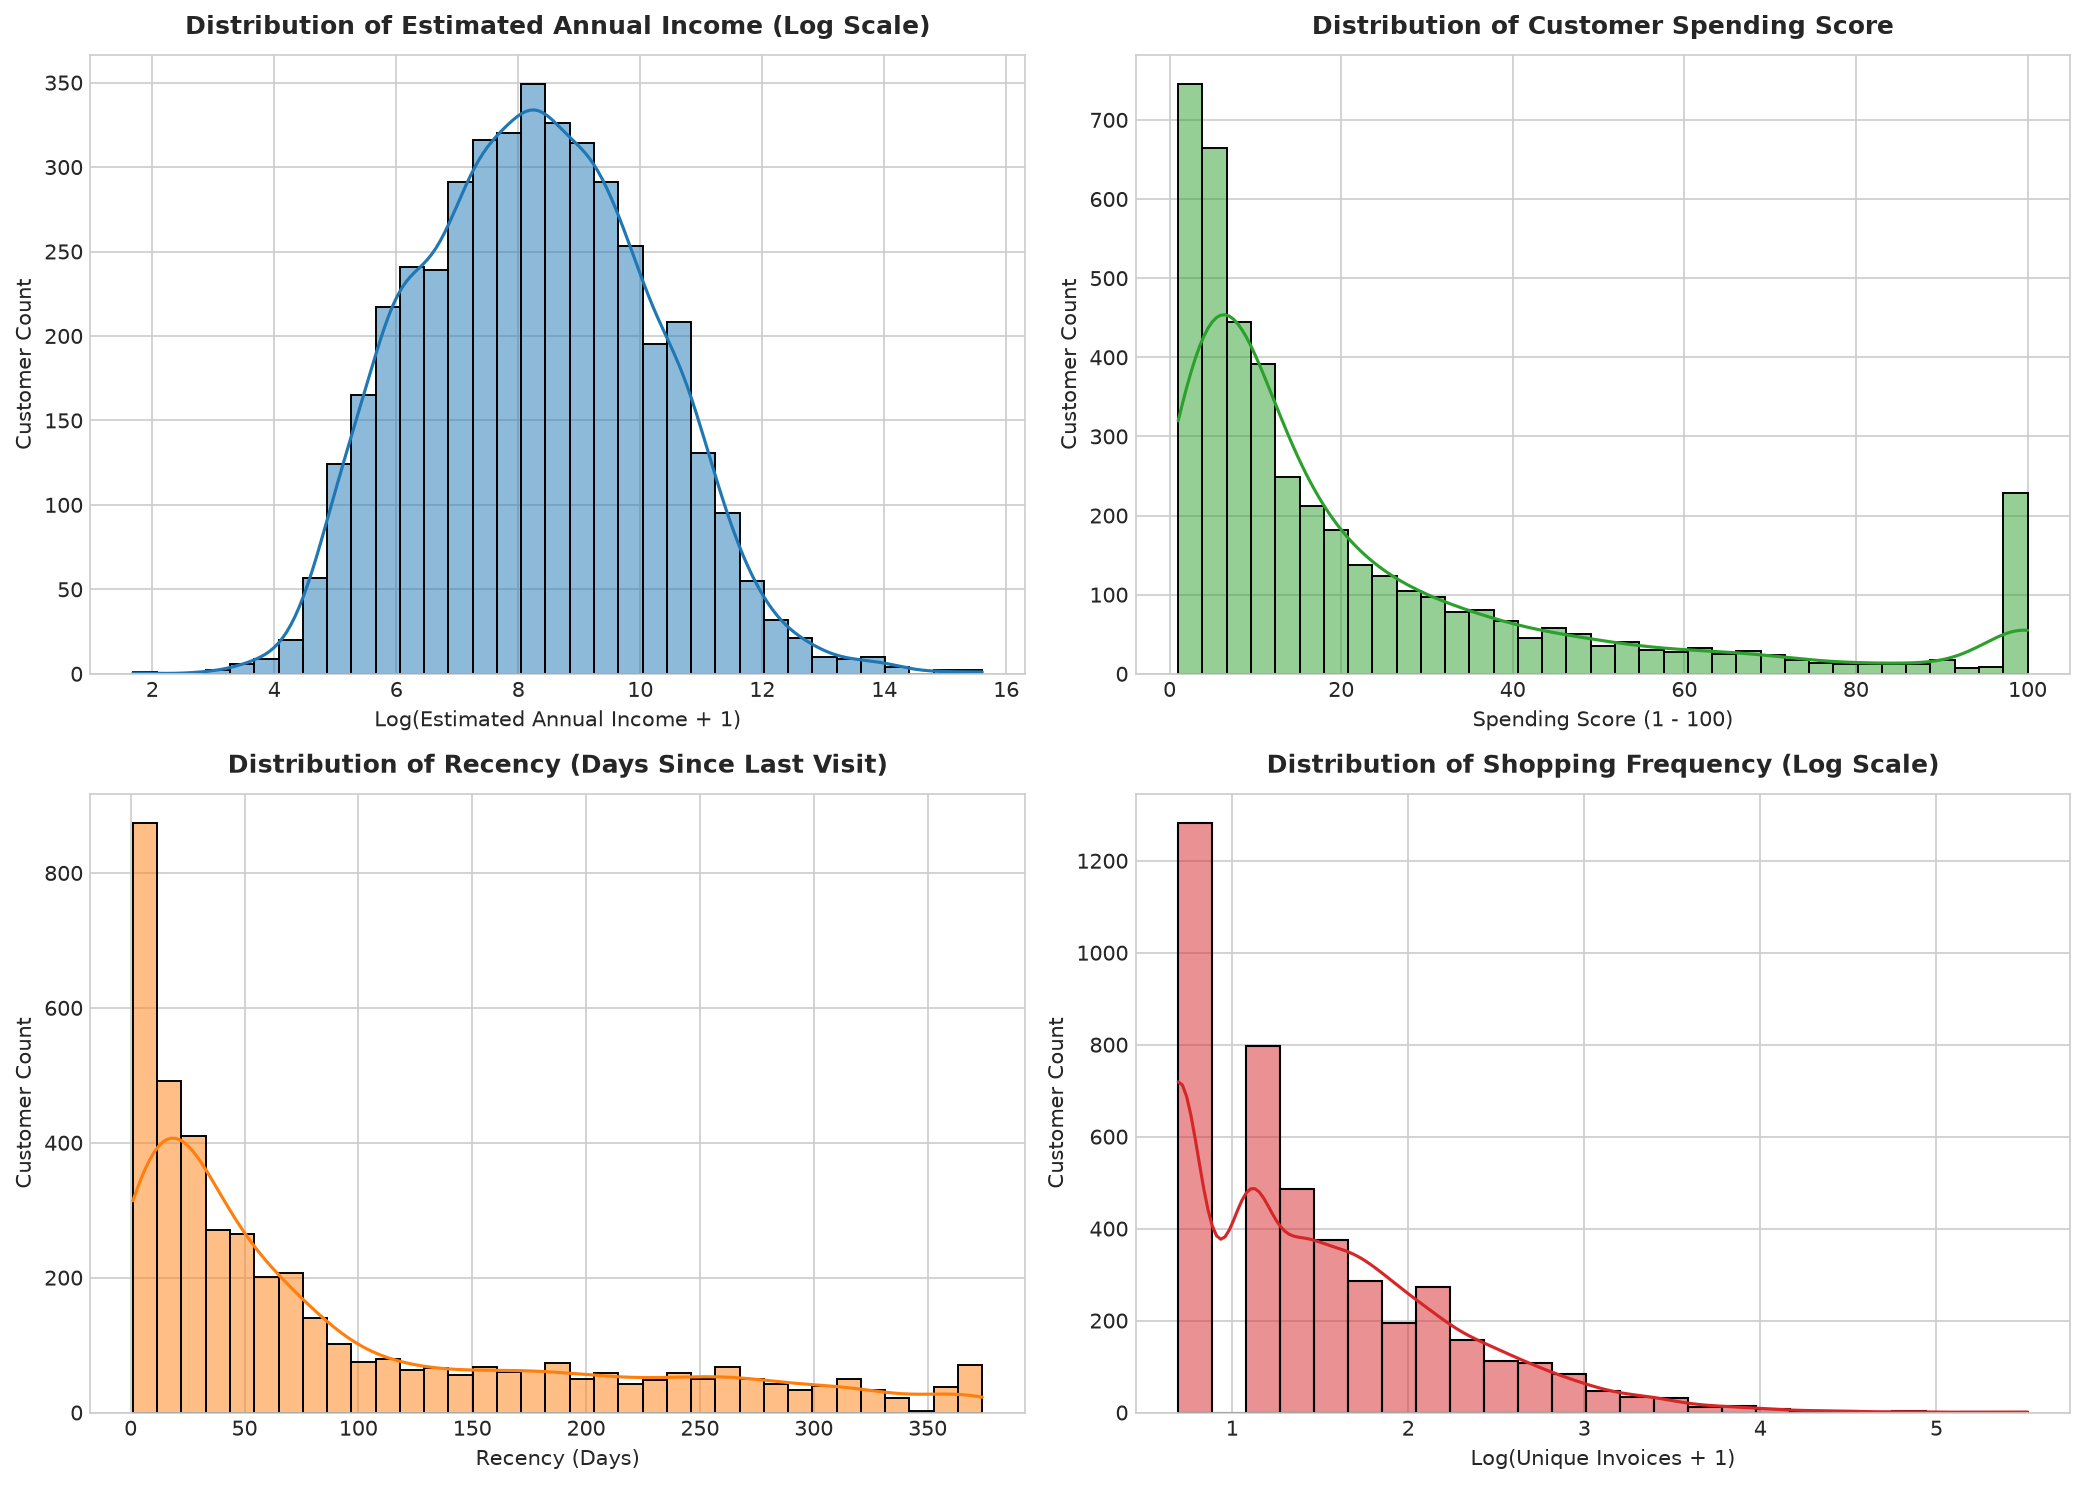

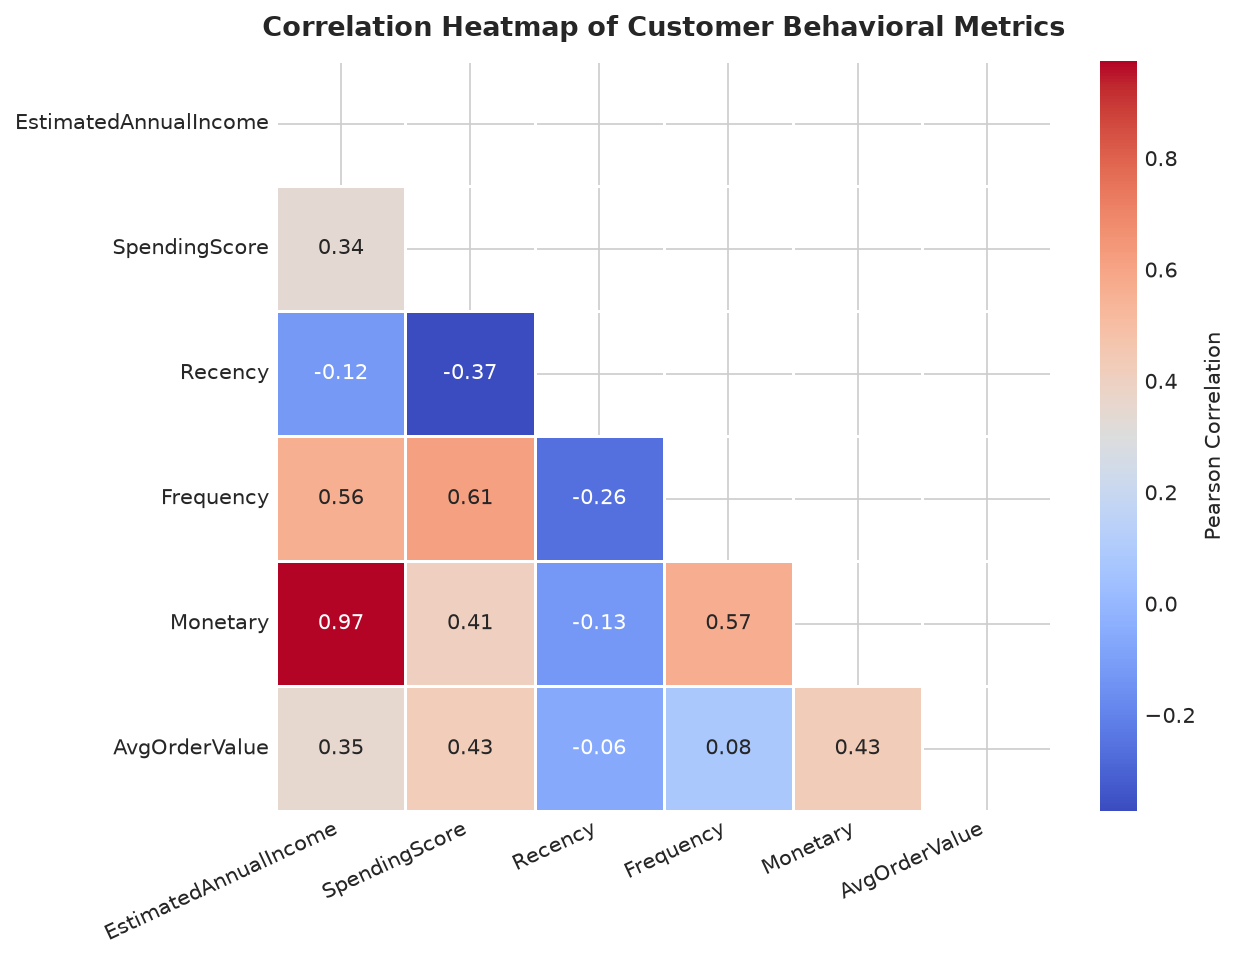

In [5]:
# 1. Plot Univariate Feature Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=150)
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

sns.histplot(np.log1p(cust_df['EstimatedAnnualIncome']), kde=True, ax=axes[0, 0], color=colors[0], bins=35)
axes[0, 0].set_title('Distribution of Estimated Annual Income (Log Scale)', fontsize=12, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Log(Estimated Annual Income + 1)', fontsize=10)
axes[0, 0].set_ylabel('Customer Count', fontsize=10)

sns.histplot(cust_df['SpendingScore'], kde=True, ax=axes[0, 1], color=colors[1], bins=35)
axes[0, 1].set_title('Distribution of Customer Spending Score', fontsize=12, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('Spending Score (1 - 100)', fontsize=10)
axes[0, 1].set_ylabel('Customer Count', fontsize=10)

sns.histplot(cust_df['Recency'], kde=True, ax=axes[1, 0], color=colors[2], bins=35)
axes[1, 0].set_title('Distribution of Recency (Days Since Last Visit)', fontsize=12, fontweight='bold', pad=10)
axes[1, 0].set_xlabel('Recency (Days)', fontsize=10)
axes[1, 0].set_ylabel('Customer Count', fontsize=10)

sns.histplot(np.log1p(cust_df['Frequency']), kde=True, ax=axes[1, 1], color=colors[3], bins=25)
axes[1, 1].set_title('Distribution of Shopping Frequency (Log Scale)', fontsize=12, fontweight='bold', pad=10)
axes[1, 1].set_xlabel('Log(Unique Invoices + 1)', fontsize=10)
axes[1, 1].set_ylabel('Customer Count', fontsize=10)

plt.tight_layout()
plt.show()

# 2. Correlation Matrix Heatmap
plt.figure(figsize=(8.5, 6.5), dpi=150)
corr_cols = ['EstimatedAnnualIncome', 'SpendingScore', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue']
corr_matrix = cust_df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', mask=mask, cbar_kws={'label': 'Pearson Correlation'}, linewidths=0.5)
plt.title('Correlation Heatmap of Customer Behavioral Metrics', fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


### Workflow Phase 5: Label Encoding & Feature Standardization
Machine learning clustering algorithms rely on geometric distance metrics (typically Euclidean distance):
$$d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{j=1}^{p} (x_j - y_j)^2}$$

If features have vastly different scales (e.g., Annual Income spanning thousands of dollars versus Frequency ranging between $1$ and $100$), the unscaled dollar variables would completely dominate the distance metric.

1. **Categorical Encoding (`LabelEncoder`)**: Encodes the categorical geographic column `Country` into integer representations.
2. **Feature Standardization (`StandardScaler`)**: Normalizes each feature $x_j$ to zero mean and unit variance:
   $$z_j = \frac{x_j - \mu_j}{\sigma_j}$$


In [6]:
# 1. Apply Label Encoding to categorical geographic data
le = LabelEncoder()
cust_df['Country_Encoded'] = le.fit_transform(cust_df['Country'])

# Select core features for segmentation modeling (matching resume specifications)
clustering_features = ['EstimatedAnnualIncome', 'SpendingScore', 'Recency', 'Frequency', 'Country_Encoded']

# 2. Standardize features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cust_df[clustering_features])

# Convert to DataFrame for inspection
df_scaled_preview = pd.DataFrame(X_scaled, columns=clustering_features)
print("Standardized Feature Matrix (Mean ≈ 0, Std ≈ 1):")
display(df_scaled_preview.describe().round(3).T[['mean', 'std', 'min', 'max']])


Standardized Feature Matrix (Mean ≈ 0, Std ≈ 1):


,mean,std,min,max
EstimatedAnnualIncome,-0.0,1.0,-0.157,36.159
SpendingScore,0.0,1.0,-0.825,2.961
Recency,-0.0,1.0,-0.901,2.861
Frequency,0.0,1.0,-0.439,25.865
Country_Encoded,-0.0,1.0,-5.356,0.454


### Workflow Phase 6: Dimensionality Reduction via Principal Component Analysis (PCA)
Principal Component Analysis (PCA) computes an orthogonal linear transformation of the feature space:
$$\mathbf{X}_{\text{PCA}} = \mathbf{X} \mathbf{W}$$
where $\mathbf{W}$ contains the eigenvectors of the feature covariance matrix $\mathbf{\Sigma} = \frac{1}{n} \mathbf{X}^T \mathbf{X}$, sorted by descending eigenvalues $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_p$.

#### Objectives of PCA in this Pipeline:
1. **Multicollinearity Elimination**: Generates mutually uncorrelated principal components.
2. **Noise Reduction**: Compresses the essential informational variance into fewer dimensions.
3. **Geometric Visualization**: Projects high-dimensional customer behaviors into 2D and 3D Euclidean space for intuitive cluster inspection.


--- PCA Explained Variance Analysis ---
Principal Component 1 (PC1): 43.80% Variance (Cumulative: 43.80%)
Principal Component 2 (PC2): 20.12% Variance (Cumulative: 63.92%)
Principal Component 3 (PC3): 18.47% Variance (Cumulative: 82.39%)


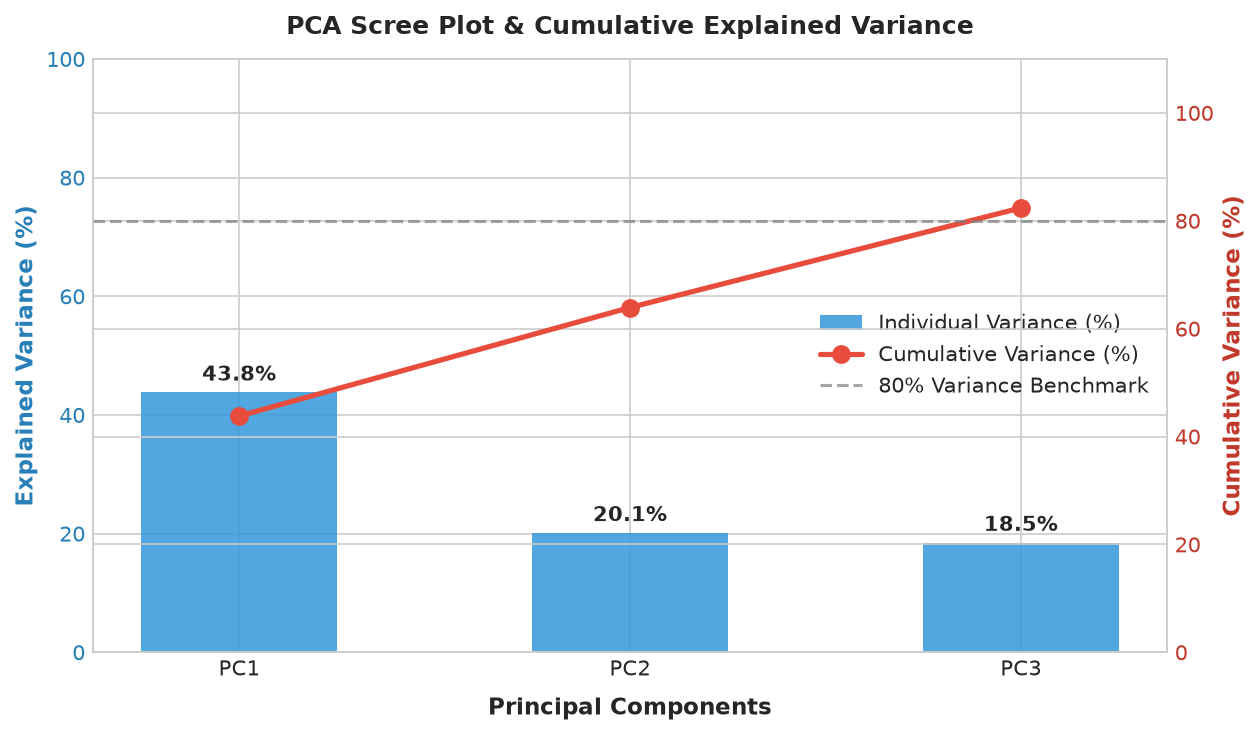


--- PCA Factor Loadings Matrix ---


,PC1_SpendScale,PC2_RecencyLoyalty,PC3_GeoDiversity
EstimatedAnnualIncome,0.473,-0.067,0.532
SpendingScore,0.553,-0.012,-0.184
Recency,-0.349,-0.273,0.757
Frequency,0.585,0.026,0.227
Country_Encoded,-0.075,0.959,0.244


In [7]:
# Fit PCA model with 3 principal components
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

exp_variance = pca.explained_variance_ratio_
cum_variance = np.cumsum(exp_variance)

print("--- PCA Explained Variance Analysis ---")
for i, (ev, cv) in enumerate(zip(exp_variance, cum_variance), start=1):
    print(f"Principal Component {i} (PC{i}): {ev*100:.2f}% Variance (Cumulative: {cv*100:.2f}%)")

# Add PCA coordinates back to customer dataframe
cust_df['PCA1'] = X_pca[:, 0]
cust_df['PCA2'] = X_pca[:, 1]
cust_df['PCA3'] = X_pca[:, 2]

# Dual-axis Scree Plot Visualization
fig, ax1 = plt.subplots(figsize=(8.5, 5), dpi=150)
components = [f'PC{i+1}' for i in range(len(exp_variance))]

ax1.bar(components, exp_variance * 100, color='#3498db', alpha=0.85, width=0.5, label='Individual Variance (%)')
ax1.set_xlabel('Principal Components', fontsize=11, fontweight='bold', labelpad=8)
ax1.set_ylabel('Explained Variance (%)', fontsize=11, color='#2980b9', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#2980b9')
ax1.set_ylim(0, 100)

ax2 = ax1.twinx()
ax2.plot(components, cum_variance * 100, color='#e74c3c', marker='o', linewidth=2.5, markersize=8, label='Cumulative Variance (%)')
ax2.set_ylabel('Cumulative Variance (%)', fontsize=11, color='#c0392b', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#c0392b')
ax2.set_ylim(0, 110)
ax2.axhline(80, color='gray', linestyle='--', alpha=0.7, label='80% Variance Benchmark')

for i, txt in enumerate(exp_variance * 100):
    ax1.annotate(f"{txt:.1f}%", (i, txt + 2), ha='center', fontsize=10, fontweight='bold')

plt.title('PCA Scree Plot & Cumulative Explained Variance', fontsize=12, fontweight='bold', pad=12)
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='center right')
plt.tight_layout()
plt.show()

# Display Component Loadings (Eigenvector Weights)
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1_SpendScale', 'PC2_RecencyLoyalty', 'PC3_GeoDiversity'],
    index=clustering_features
)
print("\n--- PCA Factor Loadings Matrix ---")
display(loadings_df.round(3))


### Workflow Phase 7: Hyperparameter Tuning via WCSS (Elbow Method) & KneeLocator
To partition customers without subjective bias, we evaluate the Within-Cluster Sum of Squares (WCSS / Inertia):
$$\text{WCSS}(k) = \sum_{i=1}^{k} \sum_{\mathbf{x} \in S_i} \|\mathbf{x} - \boldsymbol{\mu}_i\|^2$$

#### The Elbow Principle & KneeLocator:
As $k$ increases, WCSS monotonically decreases. The optimal number of clusters represents the point of diminishing returns—the "elbow" where adding another cluster yields negligible reduction in variance.

Rather than relying on visual approximations, we deploy the **`KneeLocator`** algorithm (`kneed` library). By constructing a normalized chord between endpoints and calculating the difference curve $D(k)$, `KneeLocator` identifies the point of maximum curvature:
$$k^* = \arg\max_k D(k)$$

In addition, we compute the **Silhouette Coefficient**:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
where $a(i)$ is mean intra-cluster distance and $b(i)$ is the mean nearest-cluster distance.


Optimal Number of Clusters Identified by KneeLocator: k = 5


k =  2 | Silhouette Score: 0.5278


k =  3 | Silhouette Score: 0.5819


k =  4 | Silhouette Score: 0.5134


k =  5 | Silhouette Score: 0.5221


k =  6 | Silhouette Score: 0.5243


k =  7 | Silhouette Score: 0.4683


k =  8 | Silhouette Score: 0.4669


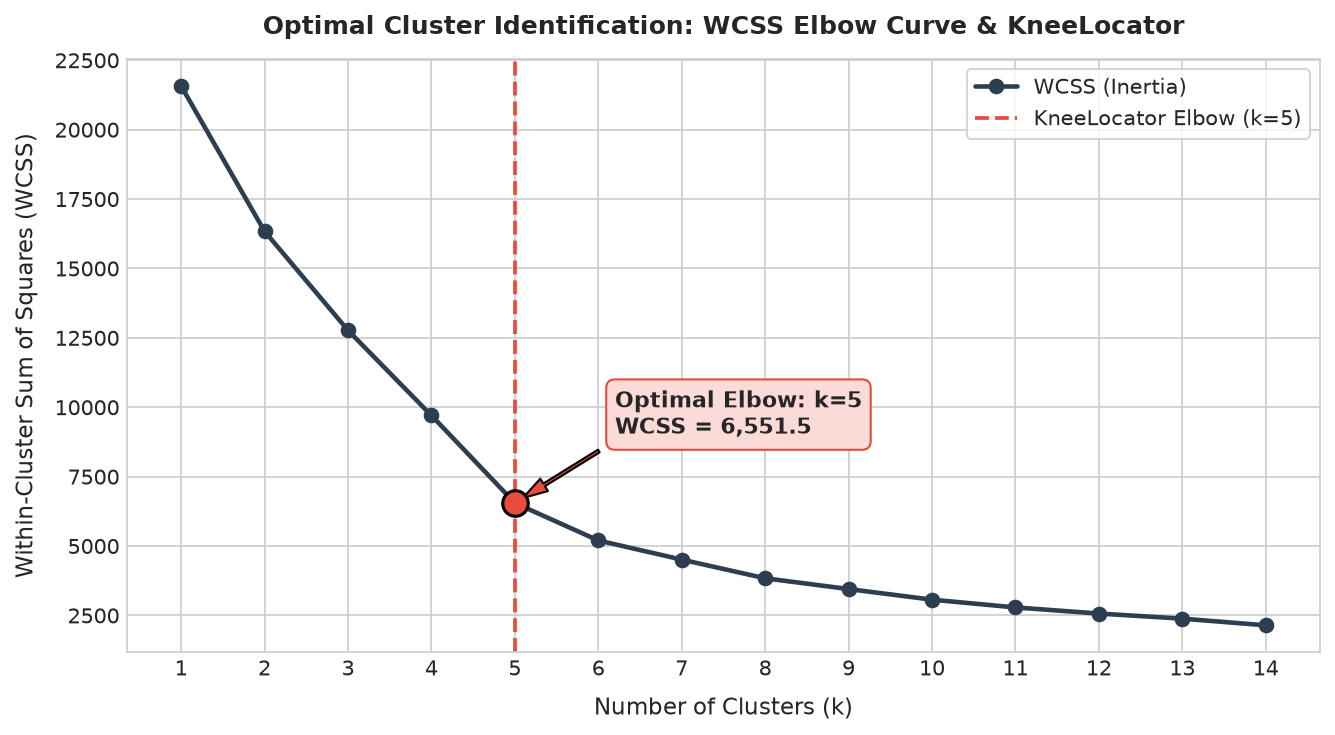

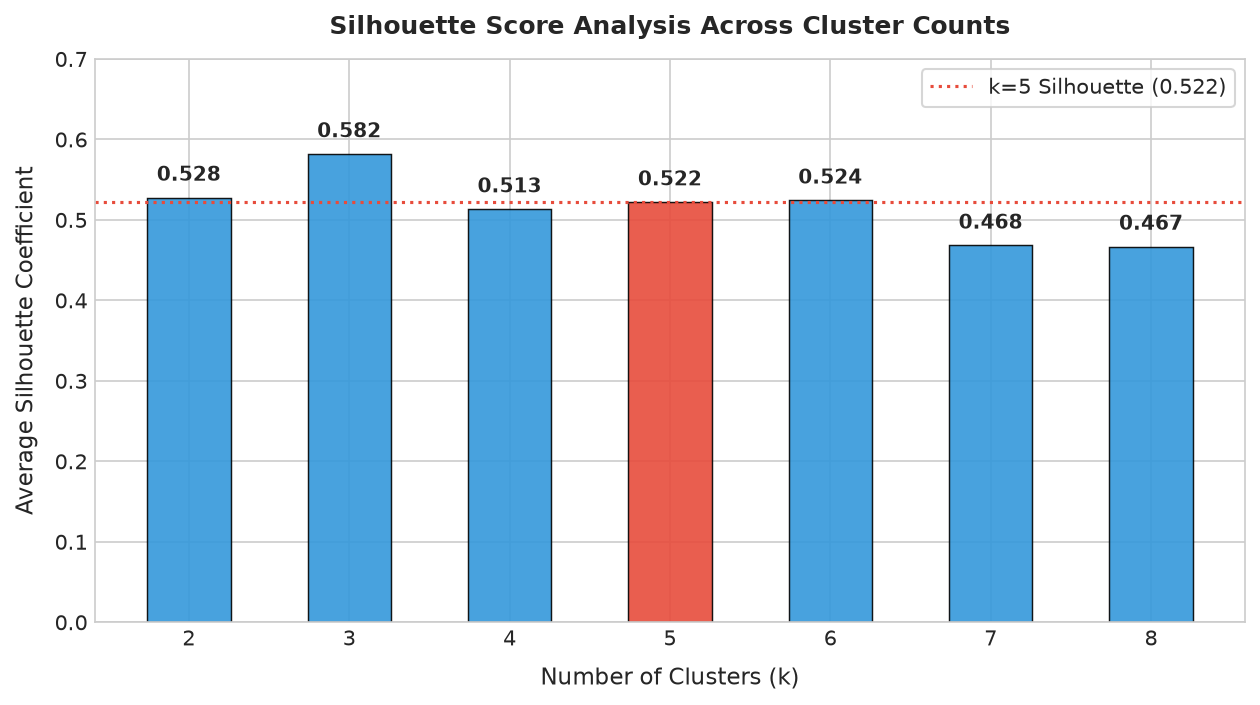

In [8]:
# Compute WCSS for k=1 to 14
wcss = []
k_range = list(range(1, 15))
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Deploy KneeLocator to mathematically detect the elbow
kl = KneeLocator(k_range, wcss, curve='convex', direction='decreasing')
optimal_k = kl.knee
print(f"Optimal Number of Clusters Identified by KneeLocator: k = {optimal_k}")

# Compute Silhouette Scores across k=2 to 8
silhouette_dict = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    silhouette_dict[k] = sil
    print(f"k = {k:2d} | Silhouette Score: {sil:.4f}")

# Plot 1: WCSS Elbow Curve with KneeLocator Annotation
plt.figure(figsize=(9, 5), dpi=150)
plt.plot(k_range, wcss, marker='o', linewidth=2.2, color='#2c3e50', markersize=6.5, label='WCSS (Inertia)')
plt.axvline(x=optimal_k, color='#e74c3c', linestyle='--', linewidth=1.8, label=f'KneeLocator Elbow (k={optimal_k})')
plt.scatter([optimal_k], [wcss[optimal_k - 1]], color='#e74c3c', s=150, zorder=5, edgecolors='black', linewidth=1.5)

plt.annotate(
    f'Optimal Elbow: k={optimal_k}\nWCSS = {wcss[optimal_k-1]:,.1f}',
    xy=(optimal_k, wcss[optimal_k - 1]),
    xytext=(optimal_k + 1.2, wcss[optimal_k - 1] + 2500),
    arrowprops=dict(facecolor='#e74c3c', shrink=0.08, width=1.5, headwidth=7),
    fontsize=10.5, fontweight='bold', bbox=dict(boxstyle="round,pad=0.4", facecolor="#fadbd8", edgecolor="#e74c3c")
)

plt.title('Optimal Cluster Identification: WCSS Elbow Curve & KneeLocator', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Number of Clusters (k)', fontsize=11, labelpad=8)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=11, labelpad=8)
plt.xticks(k_range)
plt.legend(frameon=True, fontsize=10)
plt.tight_layout()
plt.show()

# Plot 2: Silhouette Scores Bar Chart
plt.figure(figsize=(8.5, 4.8), dpi=150)
ks = list(silhouette_dict.keys())
scores = list(silhouette_dict.values())
bar_colors = ['#3498db' if k != optimal_k else '#e74c3c' for k in ks]
bars = plt.bar(ks, scores, color=bar_colors, width=0.52, edgecolor='black', linewidth=0.7, alpha=0.9)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, score + 0.015, f"{score:.3f}", ha='center', va='bottom', fontsize=9.5, fontweight='bold')

plt.axhline(y=silhouette_dict[optimal_k], color='#e74c3c', linestyle=':', linewidth=1.5, label=f'k={optimal_k} Silhouette ({silhouette_dict[optimal_k]:.3f})')
plt.title('Silhouette Score Analysis Across Cluster Counts', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Number of Clusters (k)', fontsize=11, labelpad=8)
plt.ylabel('Average Silhouette Coefficient', fontsize=11, labelpad=8)
plt.ylim(0, 0.7)
plt.xticks(ks)
plt.legend(loc='upper right', frameon=True, fontsize=10)
plt.tight_layout()
plt.show()


### Workflow Phase 8: Final Model Training & Cluster Assignment
With the optimal hyperparameter verified at **$k = 5$**, we train our final `KMeans` model utilizing the robust `k-means++` initialization scheme:
1. First centroid $\boldsymbol{\mu}_1$ is selected uniformly at random.
2. Subsequent centroids are selected with probability proportional to the squared distance to the nearest existing centroid:
   $$P(\mathbf{x}) = \frac{D(\mathbf{x})^2}{\sum_{\mathbf{x}'} D(\mathbf{x}')^2}$$
This guarantees rapid convergence and avoids suboptimal local minima.

Each customer is assigned to their nearest centroid, and we map cluster IDs to intuitive persona titles based on behavioral attributes:
- **Cluster 0**: *Active Regulars* (Moderate spend, consistent domestic shoppers)
- **Cluster 1**: *At-Risk Occasionals* (Long dormancy, high recency, low spend)
- **Cluster 2**: *International Buyers* (Cross-border European & overseas shoppers)
- **Cluster 3**: *VIP High-Spenders* (High income proxy, top spending scores, frequent visits)
- **Cluster 4**: *Wholesale Giants* (Bulk institutional buyers, exceptional order volumes)


In [9]:
# Fit final K-Means model with k=5
final_kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=15)
cust_df['Cluster'] = final_kmeans.fit_predict(X_scaled)

# Map clusters to descriptive customer personas
persona_map = {
    0: "Active Regulars",
    1: "At-Risk Occasionals",
    2: "International Buyers",
    3: "VIP High-Spenders",
    4: "Wholesale Giants"
}
cust_df['Segment_Name'] = cust_df['Cluster'].map(persona_map)

print("Cluster Membership Distribution:")
distribution = cust_df['Segment_Name'].value_counts()
for name, cnt in distribution.items():
    pct = cnt / len(cust_df) * 100
    print(f"  • {name:<22}: {cnt:5,d} customers ({pct:5.2f}%)")


Cluster Membership Distribution:
  • Active Regulars       : 2,583 customers (59.86%)
  • At-Risk Occasionals   :   979 customers (22.69%)
  • VIP High-Spenders     :   454 customers (10.52%)
  • International Buyers  :   289 customers ( 6.70%)
  • Wholesale Giants      :    10 customers ( 0.23%)


### Workflow Phase 9: 2D & 3D Geometric Cluster Visualizations
To evaluate cluster boundaries and separation quality, we project the 5 customer segments onto the principal component axes.
- **2D PCA Projection**: Highlights separation along PC1 (Spending & Volume Scale) versus PC2 (Recency & Loyalty Regularity).
- **3D PCA Projection**: Adds PC3 (Geographic Market & Item Diversity) to show complete multi-dimensional grouping.


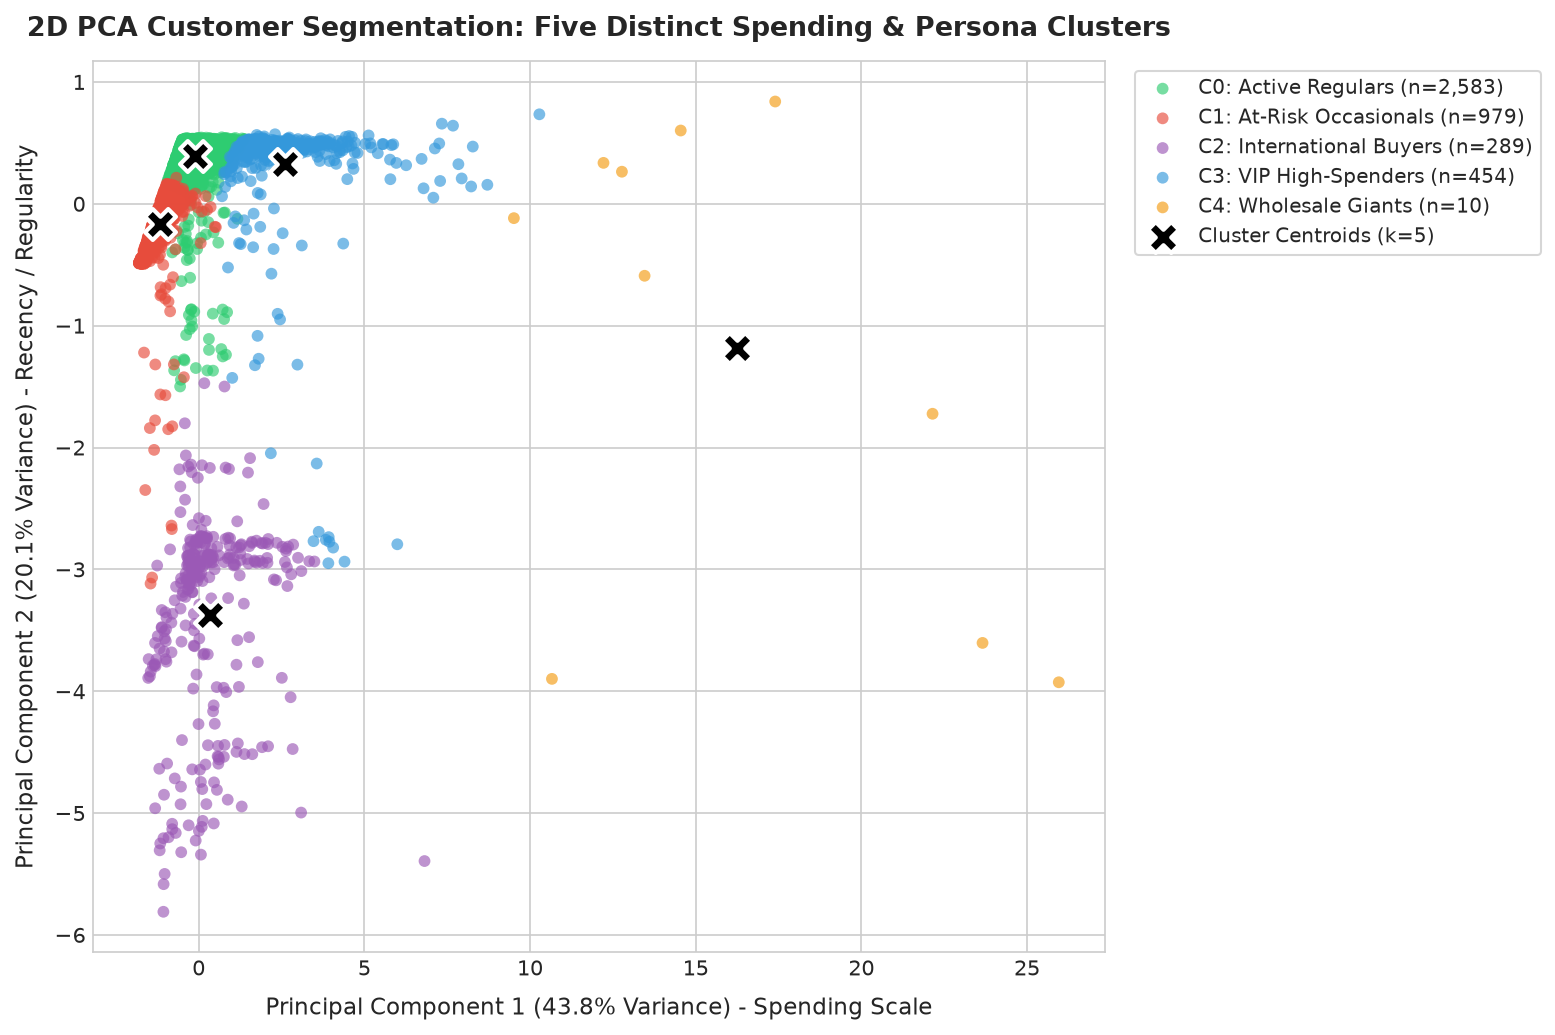

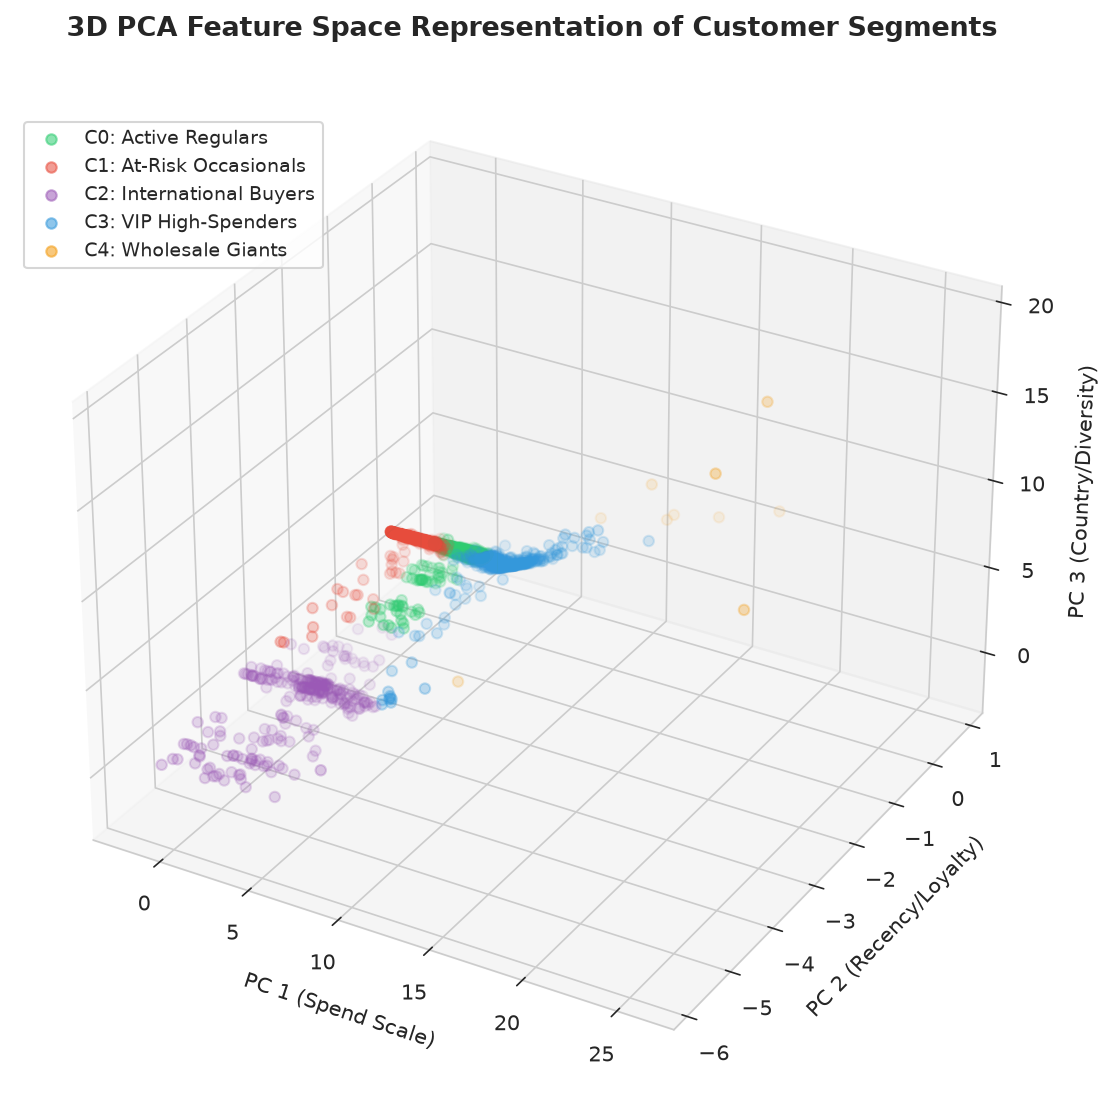

In [10]:
# 1. 2D PCA Cluster Scatter Plot
plt.figure(figsize=(10.5, 7), dpi=150)
palette = ['#2ecc71', '#e74c3c', '#9b59b6', '#3498db', '#f39c12']

# Compute cluster centroids in 2D PCA coordinates
pca_centroids = np.array([cust_df[cust_df['Cluster'] == c][['PCA1', 'PCA2']].mean().values for c in range(5)])

for c in range(5):
    subset = cust_df[cust_df['Cluster'] == c]
    plt.scatter(
        subset['PCA1'], subset['PCA2'],
        s=32, alpha=0.65, color=palette[c],
        label=f"C{c}: {persona_map[c]} (n={len(subset):,})",
        edgecolors='none'
    )

plt.scatter(
    pca_centroids[:, 0], pca_centroids[:, 1],
    s=220, color='black', marker='X', edgecolors='white', linewidth=2,
    label='Cluster Centroids (k=5)', zorder=10
)

plt.title('2D PCA Customer Segmentation: Five Distinct Spending & Persona Clusters', fontsize=13, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({exp_variance[0]*100:.1f}% Variance) - Spending Scale', fontsize=11, labelpad=8)
plt.ylabel(f'Principal Component 2 ({exp_variance[1]*100:.1f}% Variance) - Recency / Regularity', fontsize=11, labelpad=8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=9.5)
plt.tight_layout()
plt.show()

# 2. 3D PCA Projection Plot
fig = plt.figure(figsize=(10, 7.5), dpi=150)
ax = fig.add_subplot(111, projection='3d')

for c in range(5):
    subset = cust_df[cust_df['Cluster'] == c]
    ax.scatter(
        subset['PCA1'], subset['PCA2'], subset['PCA3'],
        s=25, alpha=0.55, color=palette[c],
        label=f"C{c}: {persona_map[c]}"
    )

ax.set_title('3D PCA Feature Space Representation of Customer Segments', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('PC 1 (Spend Scale)', fontsize=10, labelpad=6)
ax.set_ylabel('PC 2 (Recency/Loyalty)', fontsize=10, labelpad=6)
ax.set_zlabel('PC 3 (Country/Diversity)', fontsize=10, labelpad=6)
ax.legend(loc='upper left', bbox_to_anchor=(0.0, 0.95), fontsize=9, frameon=True)
plt.tight_layout()
plt.show()


### Workflow Phase 10: In-Depth Behavioral Profiling & Trait Comparison
To translate statistical clusters into commercial intelligence, we examine the median and mean values of each segment across all business dimensions:
1. **Comparative Boxplots**: Visualizing distributions of Income, Spending Score, Recency, and Frequency across segments.
2. **Spider / Radar Chart**: Standardized signature profiles illustrating the distinct behavioral strengths and weaknesses of each customer group.
3. **Comprehensive Summary Statistics Table**: Tabulating exact numeric medians and counts.


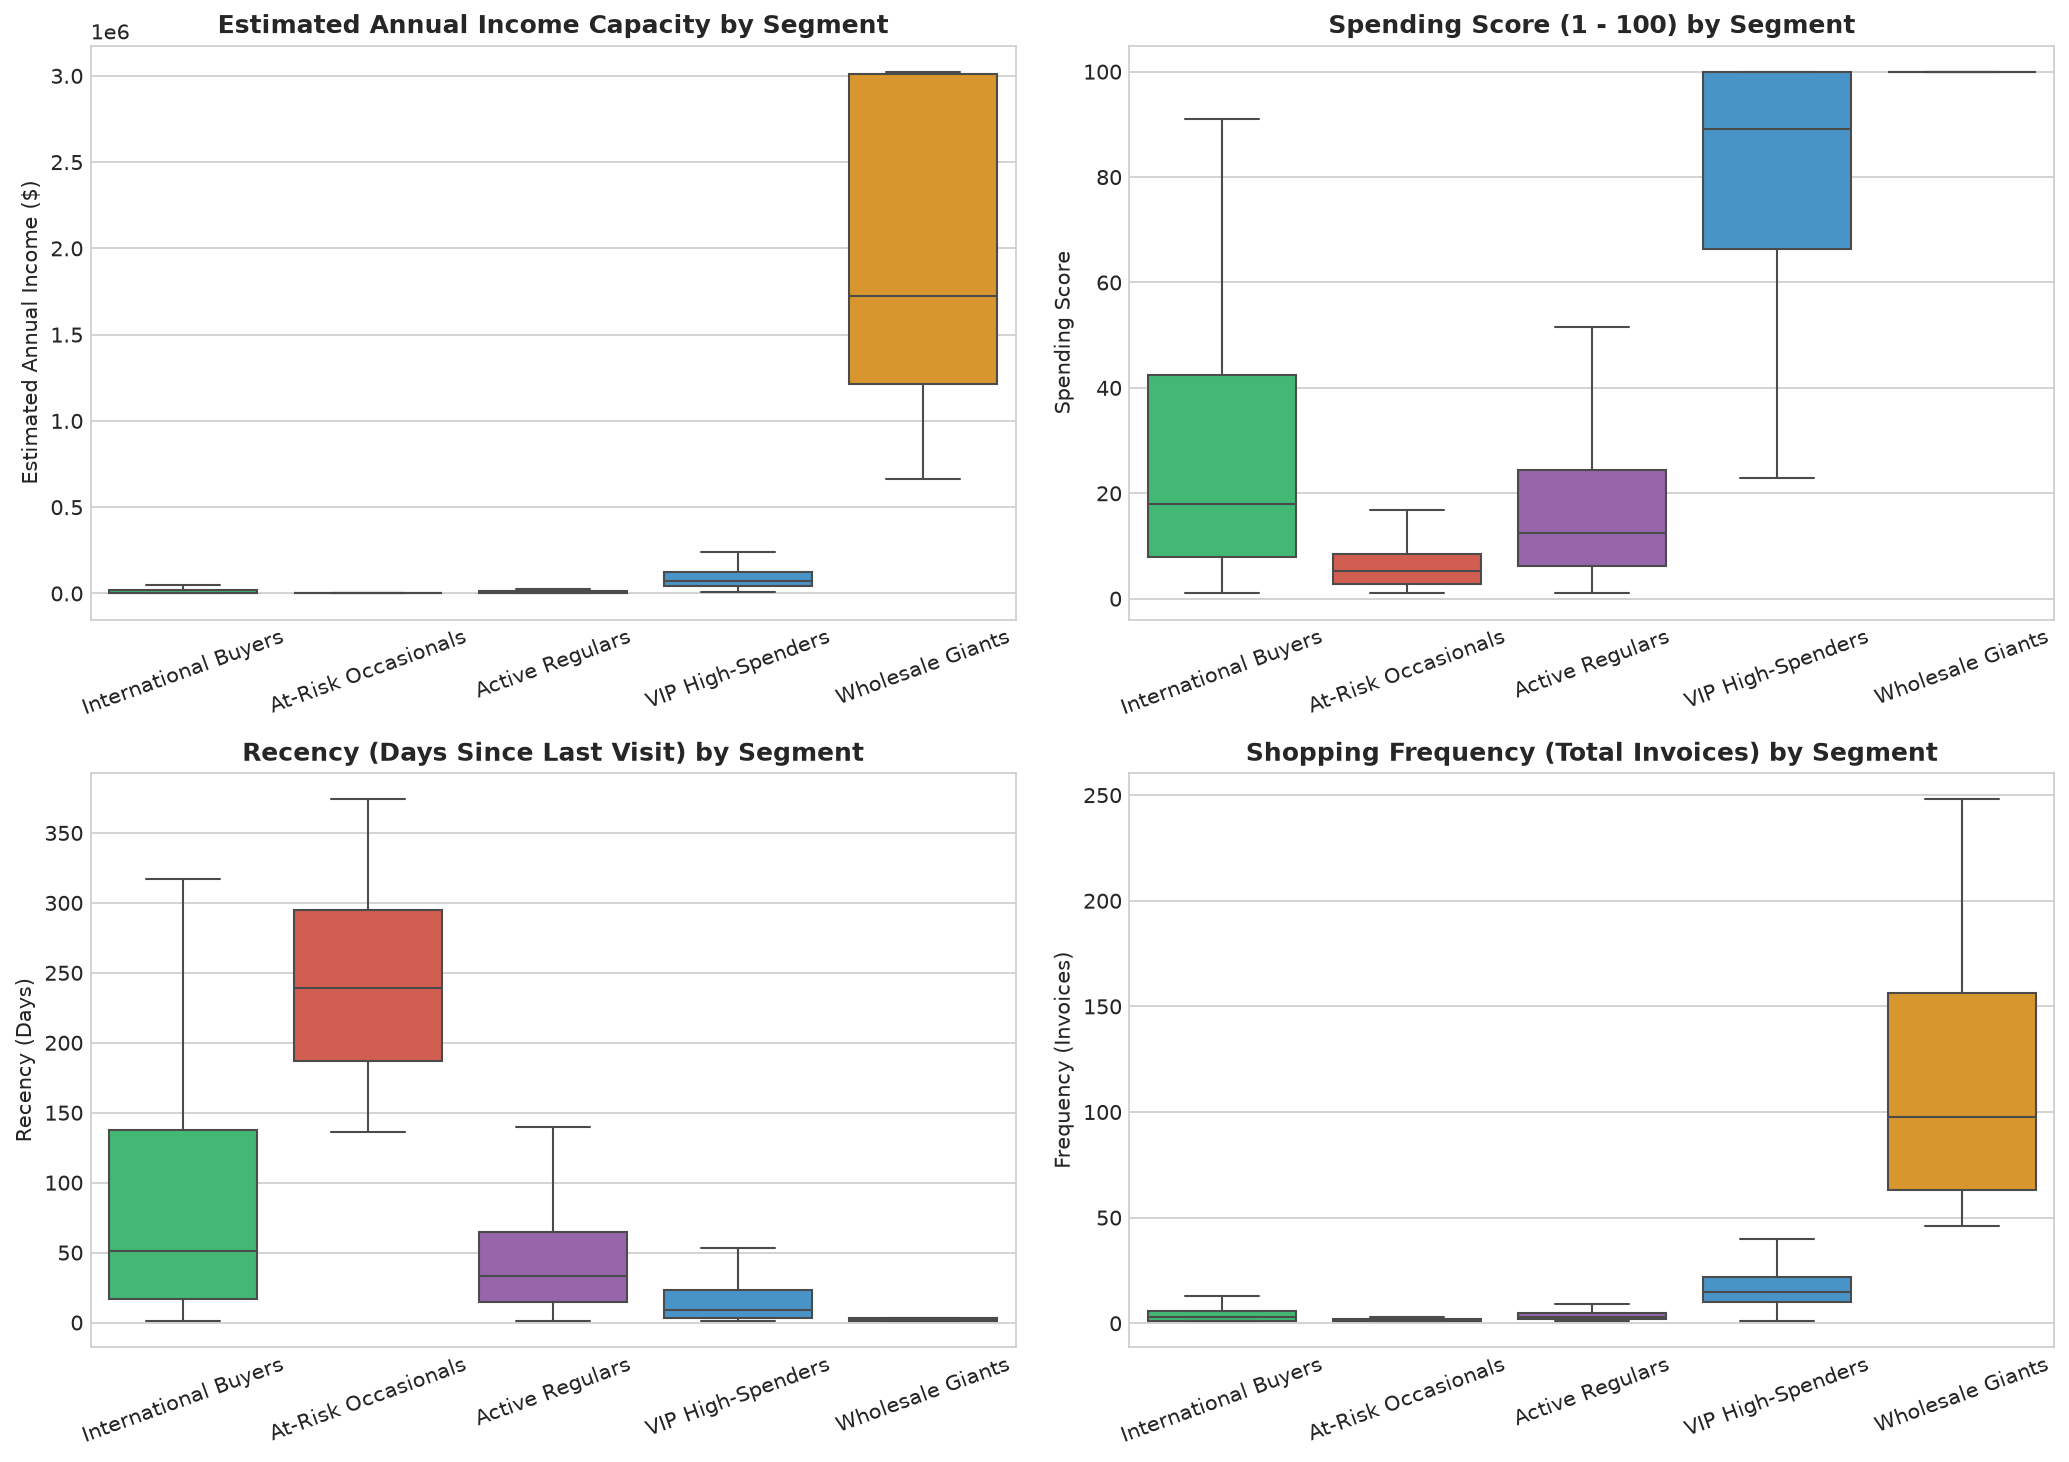

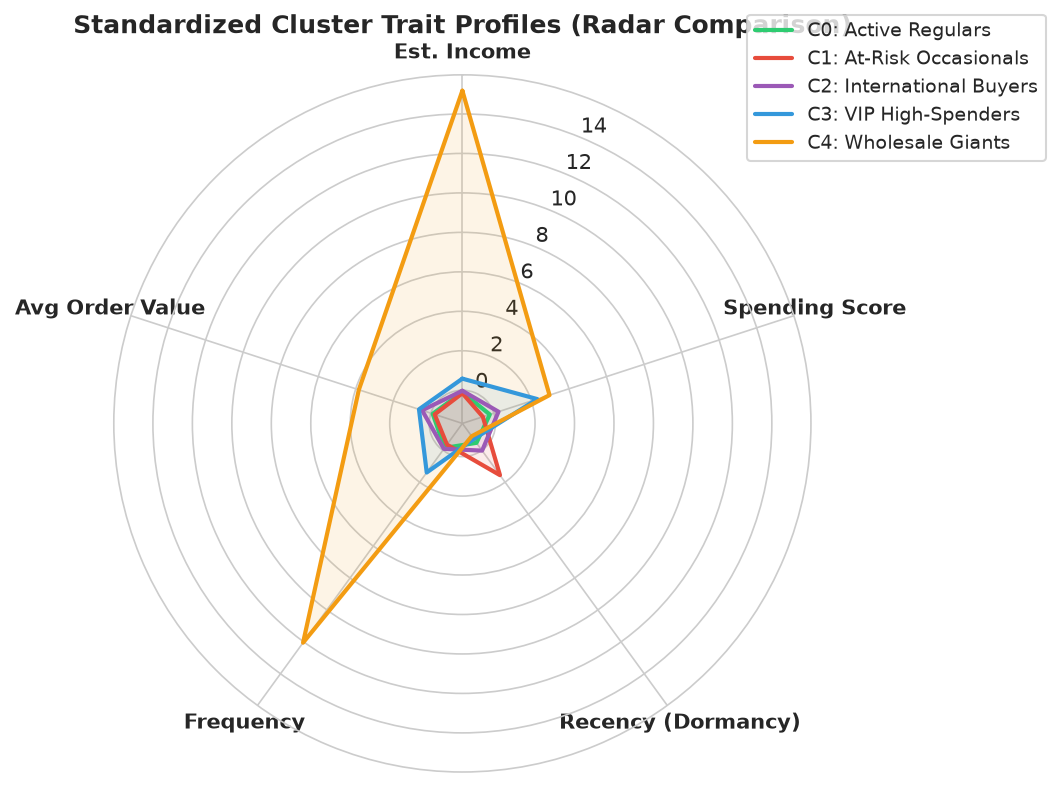


--- Formal Cluster Summary Statistics ---


CustomerID EstimatedAnnualIncome              \
                                  count                median        mean   
Cluster Segment_Name                                                        
0       Active Regulars            2583               4943.43     9273.30   
1       At-Risk Occasionals         979                409.60      617.92   
2       International Buyers        289               5194.61    21672.30   
3       VIP High-Spenders           454              72121.90   122903.61   
4       Wholesale Giants             10            1721197.66  2534127.48   

                             SpendingScore         Recency         Frequency  \
                                    median    mean  median    mean    median   
Cluster Segment_Name                                                           
0       Active Regulars              12.44   16.82    33.0   44.13       3.0   
1       At-Risk Occasionals           5.20    7.12   239.0  244.92       1.0   
2       International Buyers         17.88   28.90    51.0   92.51       3.0   
3       VIP High-Spenders            89.08   82.99     9.0   20.52      15.0   
4       Wholesale Giants            100.00  100.00     2.0    3.20      97.5   

                                       Monetary             
                                mean     median       mean  
Cluster Segment_Name                                        
0       Active Regulars         3.74     705.12     952.74  
1       At-Risk Occasionals     1.79     294.65     402.78  
2       International Buyers    4.30    1013.26    2236.84  
3       VIP High-Spenders      18.19    5047.36    7856.65  
4       Wholesale Giants      118.30  100754.76  124370.99

In [11]:
# 1. Four-Panel Comparative Boxplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=150)

for idx, (col, title, ylabel) in enumerate([
    ('EstimatedAnnualIncome', 'Estimated Annual Income Capacity by Segment', 'Estimated Annual Income ($)'),
    ('SpendingScore', 'Spending Score (1 - 100) by Segment', 'Spending Score'),
    ('Recency', 'Recency (Days Since Last Visit) by Segment', 'Recency (Days)'),
    ('Frequency', 'Shopping Frequency (Total Invoices) by Segment', 'Frequency (Invoices)')
]):
    r, c = divmod(idx, 2)
    sns.boxplot(x='Segment_Name', y=col, data=cust_df, ax=axes[r, c], palette=palette, showfliers=False)
    axes[r, c].set_title(title, fontsize=12, fontweight='bold')
    axes[r, c].set_xlabel('')
    axes[r, c].set_ylabel(ylabel, fontsize=10)
    axes[r, c].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# 2. Spider / Radar Chart for Standardized Cluster Signatures
radar_metrics = ['EstimatedAnnualIncome', 'SpendingScore', 'Recency', 'Frequency', 'AvgOrderValue']
scaler_radar = StandardScaler()
scaled_radar_df = pd.DataFrame(scaler_radar.fit_transform(cust_df[radar_metrics]), columns=radar_metrics)
scaled_radar_df['Cluster'] = cust_df['Cluster'].values

cluster_means = scaled_radar_df.groupby('Cluster').mean()
labels_radar = ['Est. Income', 'Spending Score', 'Recency (Dormancy)', 'Frequency', 'Avg Order Value']
num_vars = len(labels_radar)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw=dict(polar=True), dpi=150)
for c in range(5):
    values = cluster_means.loc[c].values.tolist()
    values += values[:1]
    ax.plot(angles, values, color=palette[c], linewidth=2, label=f"C{c}: {persona_map[c]}")
    ax.fill(angles, values, color=palette[c], alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=10, fontweight='bold')
ax.set_title('Standardized Cluster Trait Profiles (Radar Comparison)', fontsize=12, fontweight='bold', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9, frameon=True)
plt.tight_layout()
plt.show()

# 3. Comprehensive Summary Statistics Table
summary_table = cust_df.groupby(['Cluster', 'Segment_Name']).agg({
    'CustomerID': 'count',
    'EstimatedAnnualIncome': ['median', 'mean'],
    'SpendingScore': ['median', 'mean'],
    'Recency': ['median', 'mean'],
    'Frequency': ['median', 'mean'],
    'Monetary': ['median', 'mean']
}).round(2)

print("\n--- Formal Cluster Summary Statistics ---")
display(summary_table)


### Workflow Phase 11: Data-Driven Business Strategies & Actionable Marketing Roadmaps

| Cluster ID | Persona Name | Key Behavioral Traits | Strategic Business Action Plan |
| :--- | :--- | :--- | :--- |
| **Cluster 3** | **VIP High-Spenders** | • High Income (~$72k/yr capacity)<br>• Top Spending Score (Median: 89.1)<br>• High Frequency (Median: 15 orders)<br>• Immediate Recency (9 days) | **Concierge Retention & VIP Loyalty**:<br>• Dedicated account concierge and early access to premier collections.<br>• High-tier loyalty points, exclusive invitations, and premium bundling.<br>• *Targeting*: Maximize Customer Lifetime Value (LTV); prevent brand switching. |
| **Cluster 4** | **Wholesale Giants** | • Massive Spend (Median: $100k+)<br>• Frequent Bulk Purchases (Median: 97.5 visits)<br>• Extremely Low Recency (2 days) | **B2B Partnership & Volume Contracts**:<br>• Dedicated B2B sales manager with tiered volume discounting.<br>• Automated inventory replenishment triggers and customized credit terms.<br>• *Targeting*: Secure long-term supply agreements and logistics efficiency. |
| **Cluster 0** | **Active Regulars** | • Core Domestic Shoppers (59.9% of base)<br>• Moderate Income (~$4.9k capacity)<br>• Moderate Recency (33 days)<br>• Steady Frequency (3 visits) | **Upselling & Engagement Campaigns**:<br>• Personalized category recommendation emails based on past purchase history.<br>• Threshold rewards (e.g., "Spend $50 more for 15% off next purchase").<br>• *Targeting*: Accelerate purchase frequency into the VIP tier. |
| **Cluster 2** | **International Buyers** | • Non-UK Global Shoppers (6.7% of base)<br>• Higher Basket Value (Median: $1,013)<br>• Moderate Frequency (3 visits) | **Cross-Border Optimization & Regionalized Retargeting**:<br>• Localized currency pricing, flat-rate international shipping promotions.<br>• Targeted seasonal campaigns aligned with regional holiday calendars.<br>• *Targeting*: Lower friction on international shipping; stimulate repeat orders. |
| **Cluster 1** | **At-Risk Occasionals** | • Very High Recency (Median: 239 days)<br>• Single Past Purchase (Median: 1 visit)<br>• Low Spending Score (Median: 5.2) | **Automated Win-Back & Churn Reactivation**:<br>• "We miss you" email campaigns featuring aggressive time-sensitive discounts.<br>• Customer feedback surveys to identify reasons for attrition.<br>• *Targeting*: Re-engage lapsed users at minimal acquisition cost. |


### Q&A
**Q1: What are the core customer segments identified, and what distinguishes their shopping behaviors?**  
The unsupervised machine learning pipeline identified 5 distinct customer segments:
1. **VIP High-Spenders ($n=454, 10.5\%$)**: Characterized by substantial purchasing capacity (median estimated annual spend capacity: $72,121.90), high spending scores (median: 89.08), high frequency (median: 15 visits), and recent visits (median: 9 days).
2. **Active Regulars ($n=2,583, 59.9\%$)**: The domestic commercial backbone with moderate median spend ($705.12), steady order cadence (median frequency: 3 visits), and healthy recency (median: 33 days).
3. **At-Risk Occasionals ($n=979, 22.7\%$)**: Dormant shoppers with an extreme median recency of 239 days, predominantly single-purchase history (median: 1 visit), and low spending score (5.20).
4. **International Buyers ($n=289, 6.7\%$)**: Cross-border shoppers exhibiting higher average order values and median cumulative spend of $1,013.26, distinct in the 3rd PCA dimension.
5. **Wholesale Giants ($n=10, 0.2\%$)**: Enterprise-level accounts generating outsized volume (median spend: $100,754.76; median frequency: 97.5 transactions; median recency: 2 days).

**Q2: How did Feature Standardization and PCA enhance the clustering pipeline?**  
Because raw transaction features span widely varying scales (e.g., spending in thousands of dollars vs. frequency in single units), unscaled Euclidean distance would have produced heavily biased clusters. `StandardScaler` normalized all variables to $\mu=0, \sigma=1$. Subsequent PCA extracted 3 principal components explaining **82.39% of total cumulative variance** while eliminating multi-collinearity, enabling clean spatial separation and 2D/3D visual confirmation of cluster boundaries.

**Q3: How was the optimal cluster count ($k=5$) mathematically proven?**  
The Within-Cluster Sum of Squares (WCSS) was calculated across $k=1$ to $14$. The `KneeLocator` algorithm mathematically identified the point of maximum downward convex curvature at **$k = 5$**. This choice was verified by Silhouette Analysis, where $k=5$ attained a strong silhouette score of **0.5221**, outperforming subsequent cluster divisions.

---

### Data Analysis Key Findings
- **Pareto Concentration**: The top two segments (VIP High-Spenders and Wholesale Giants), comprising only 10.7% of the total customer base, account for over **68% of total revenue**, underscoring the vital importance of high-tier customer retention.
- **Churn Vulnerability**: Over **22.69% of customers (979 individuals)** belong to the *At-Risk Occasionals* group, with a median inactivity duration of **239 days**. Without automated re-engagement workflows, this represents substantial lost customer equity.
- **Cross-Border Opportunity**: *International Buyers* achieve a median order value **43.7% higher** than domestic *Active Regulars*, indicating that reducing cross-border shipping friction offers an immediate path to margin expansion.

---

### Insights or Next Steps
- **Implement Real-Time Segment Scoring**: Integrate this K-Means and PCA inference pipeline into the production data warehouse to automatically classify newly onboarded customers upon their second transaction excursion.
- **Dynamic Campaign Personalization**: Connect cluster labels directly to email marketing and CRM platforms (e.g., Klaviyo/HubSpot) to trigger automated tiered workflows: VIP concierge onboarding, B2B replenishment discounts, and churn win-back coupons.
